# Perros vs. gatos: clasificación de imágenes con una RNA

## Objetivo

Entrenar una red neuronal convolucional (`EfficientNet-B0`) que distinga fotos de perros y gatos del dataset *Asirra* (Petfinder.com y Microsoft). Como referencia, el mejor resultado publicado cuando se lanzó la competición era un SVM con un **80% de precisión**.

Las funciones reutilizables viven en `app.py` y `utils.py`; este notebook las ejecuta paso a paso y muestra los resultados.

In [1]:
import json
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from matplotlib_inline.backend_inline import set_matplotlib_formats

# JPEG keeps the photo grids light so the notebook renders quickly on GitHub.
set_matplotlib_formats("jpeg")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "src" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from app import (
    BEST_MODEL_PATH,
    CLASSES,
    EPOCHS,
    HISTORY_PATH,
    build_callbacks,
    build_generators,
    build_model,
    evaluate_model,
    prepare_dataset,
    sample_images,
    save_training_summary,
)
from utils import plot_image_grid, plot_predictions, plot_training_history

## Paso 1: carga del conjunto de datos

`prepare_dataset()` descarga el zip (~580 MB, 25.000 fotos) y extrae las imágenes directamente en `data/interim/dogs-vs-cats.noindex/{train,test}/{cat,dog}`. La etiqueta de cada foto está en su nombre de archivo (`cat.12.jpg`, `dog.7.jpg`); al moverla al nombre de la carpeta, `flow_from_directory()` puede etiquetar las imágenes automáticamente.

El 20% de cada clase se reserva para test con una semilla fija, de modo que la división es reproducible y está equilibrada. Si el dataset ya está preparado, la función no vuelve a descargarlo.

In [2]:
dataset_path = prepare_dataset()
counts = pd.DataFrame(
    {
        split: {label: len(list((dataset_path / split / label).glob("*.jpg"))) for label in CLASSES}
        for split in ("train", "test")
    }
)
counts.loc["total"] = counts.sum()
counts

,train,test
cat,10000,2500
dog,10000,2500
total,20000,5000


## Paso 2: visualización de la información de entrada

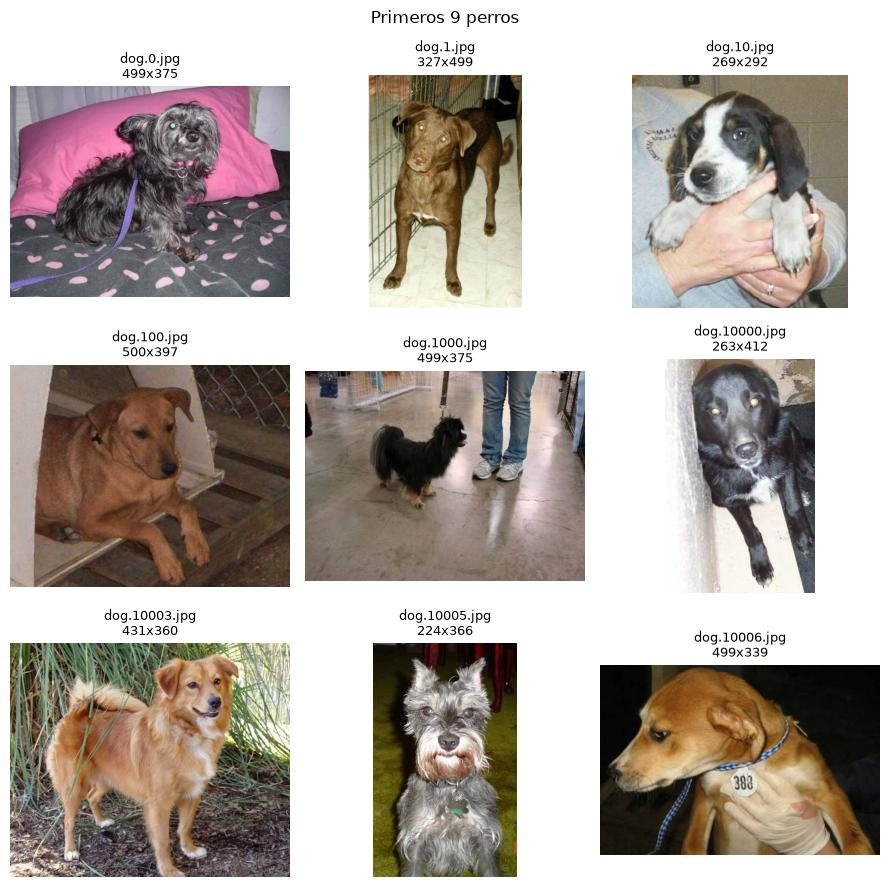

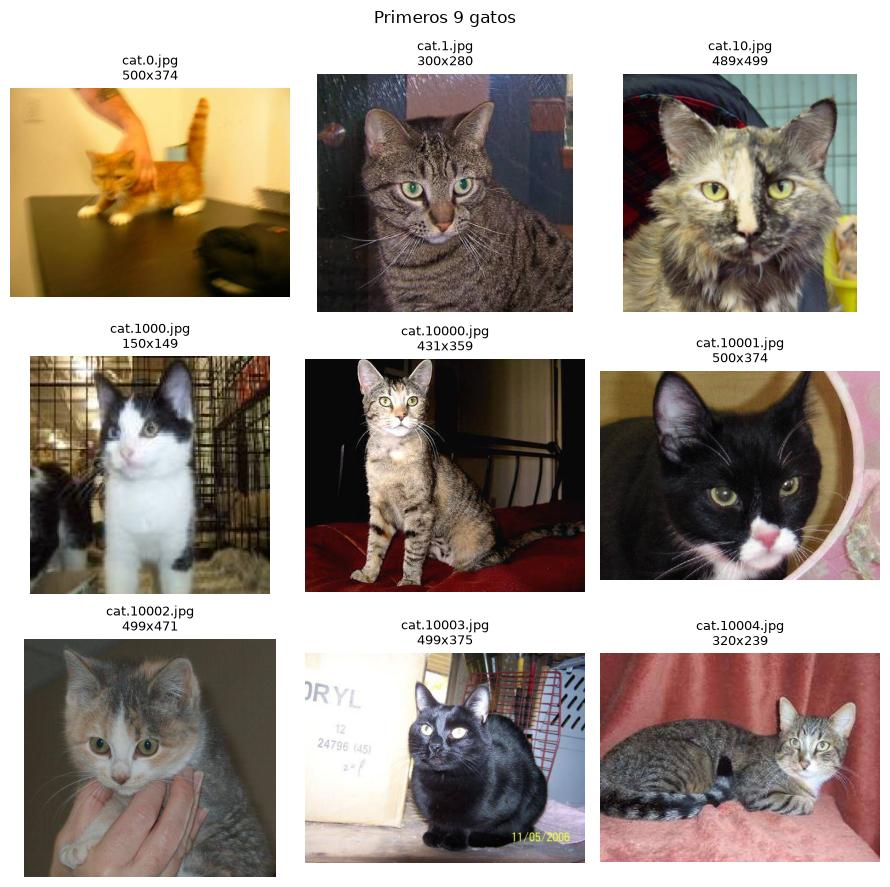

In [3]:
plot_image_grid(sample_images("dog"), "Primeros 9 perros")
plot_image_grid(sample_images("cat"), "Primeros 9 gatos")

Las fotos son a color y cada una tiene un tamaño y una proporción distintos (se indican bajo el nombre): hay retratos, fotos apaisadas, animales en una esquina y hasta varias personas u objetos en la escena. Antes de entrar a la red deben tener todas el mismo tamaño.

Las instrucciones sugieren 200×200 píxeles, pero la arquitectura del paso 3 declara `input_shape=(224, 224, 3)`, así que se redimensionan a **224×224** para que coincidan con la entrada del modelo.

Como el equipo tiene **8 GB de RAM** (menos de 12 GB), las imágenes no se cargan todas en memoria: se leen por lotes con `ImageDataGenerator` y `flow_from_directory()`. Se crean tres iteradores:

- `trdata`: 90% de la carpeta de train, con volteo horizontal aleatorio (un perro mirando a la izquierda sigue siendo un perro).
- `valdata`: el 10% restante de train, sin transformaciones. `EarlyStopping` y `ModelCheckpoint` toman sus decisiones con él, de modo que el test queda intacto para la medición final.
- `tsdata`: la carpeta de test, sin barajar para que las predicciones se correspondan con cada archivo.

No se usa `rescale=1/255` porque `EfficientNetB0` ya incluye una capa que normaliza los píxeles internamente.

In [4]:
trdata, valdata, tsdata = build_generators()
print("Índices de clase:", trdata.class_indices)
print(f"Train: {trdata.samples} | Validación: {valdata.samples} | Test: {tsdata.samples}")

images, labels = trdata[0]
print(f"Forma de un lote: {images.shape} (lote, alto, ancho, canales), etiquetas {labels.shape}")
print(f"Rango de píxeles: {images.min():.0f}-{images.max():.0f}")

Found 18000 images belonging to 2 classes.


Found 2000 images belonging to 2 classes.


Found 5000 images belonging to 2 classes.


Índices de clase: {'cat': 0, 'dog': 1}
Train: 18000 | Validación: 2000 | Test: 5000
Forma de un lote: (16, 224, 224, 3) (lote, alto, ancho, canales), etiquetas (16, 2)
Rango de píxeles: 0-255


## Paso 3: construcción de la RNA

La arquitectura carga la *backbone* convolucional de `EfficientNet-B0` sin pesos preentrenados (`weights=None`), reduce los mapas de características con `GlobalAveragePooling2D` y termina con dos capas densas. La última tiene 2 neuronas con `softmax`: una probabilidad por clase.

Para completar el modelo se compila con el optimizador **Adam**, la pérdida **`categorical_crossentropy`** (adecuada para etiquetas *one-hot* con `softmax`) y la métrica **accuracy**.

In [5]:
model = build_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,797 (16.07 MB)

 Trainable params: 4,171,774 (15.91 MB)

 Non-trainable params: 42,023 (164.16 KB)

## Paso 4: entrenamiento y optimización

Se pasan dos *callbacks* a `model.fit` (en Keras 3 `fit_generator` ya no existe; `fit` acepta los generadores directamente):

- **`ModelCheckpoint`**: guarda en `models/` el modelo cada vez que mejora la pérdida de validación (`save_best_only=True`).
- **`EarlyStopping`**: detiene el entrenamiento si `val_loss` no mejora durante 3 épocas seguidas (`patience=3`) y restaura los pesos de la mejor época.

El entrenamiento completo con las 25.000 imágenes tardó **unas 5,5 horas** en un MacBook Air M1 (CPU). Para no repetirlo cada vez que se ejecuta el notebook, la celda solo entrena si todavía no existe el modelo guardado; en caso contrario carga el historial registrado durante ese entrenamiento. Para reentrenar desde cero basta con poner `TRAIN_MODEL = True`.

Modelo ya entrenado: se carga el historial desde models/training_history.json
Épocas ejecutadas: 18 | mejor época (menor val_loss): 15


,loss,accuracy,val_loss,val_accuracy
época,,,,
1,0.6510,0.6204,0.6179,0.6720
2,0.5068,0.7496,0.4797,0.7835
3,0.4171,0.8092,0.3993,0.8155
4,0.3502,0.8509,0.4233,0.8245
5,0.2946,0.8799,0.2722,0.8900
6,0.2476,0.8986,0.3220,0.8545
7,0.2096,0.9149,0.2636,0.8935
8,0.1864,0.9245,0.2615,0.9045
9,0.1648,0.9348,0.2378,0.9120


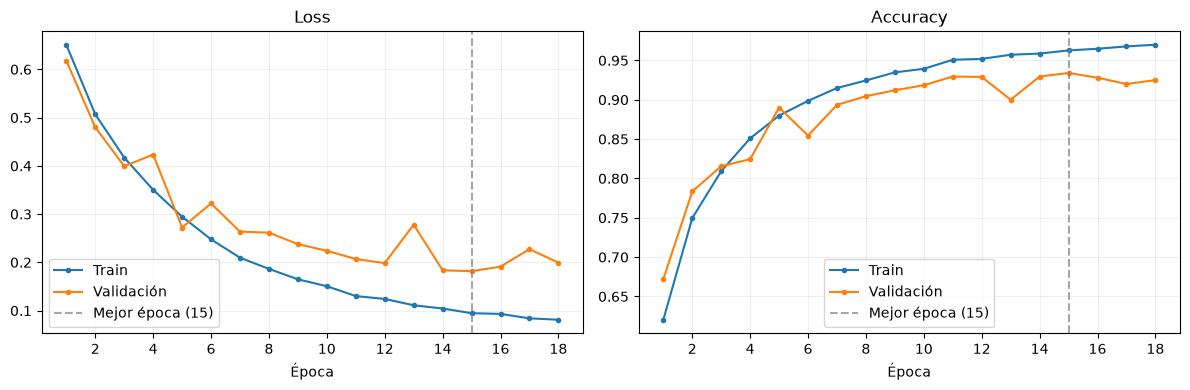

In [6]:
TRAIN_MODEL = not BEST_MODEL_PATH.exists()

if TRAIN_MODEL:
    history = model.fit(
        trdata,
        validation_data=valdata,
        epochs=EPOCHS,
        callbacks=build_callbacks(),
    )
    training_history = history.history
    best_epoch = int(np.argmin(training_history["val_loss"])) + 1
else:
    saved_training = json.loads(HISTORY_PATH.read_text())
    training_history = saved_training["history"]
    best_epoch = saved_training["best_epoch"]
    print(f"Modelo ya entrenado: se carga el historial desde {HISTORY_PATH.relative_to(PROJECT_ROOT)}")

epochs_table = pd.DataFrame(training_history, index=pd.RangeIndex(1, len(training_history["loss"]) + 1, name="época"))
print(f"Épocas ejecutadas: {len(epochs_table)} | mejor época (menor val_loss): {best_epoch}")
display(epochs_table.style.format("{:.4f}").highlight_min(subset=["val_loss"], color="lightgreen"))
plot_training_history(training_history, best_epoch=best_epoch)

### Análisis del entrenamiento

- **Épocas 1-5**: aprendizaje rápido; la precisión de validación pasa del 67% al 89%. En 4 de estas 5 épocas la validación va incluso por delante de train, porque el volteo aleatorio solo se aplica a las imágenes de entrenamiento y las hace algo más difíciles.
- **Épocas 6-15**: mejora más lenta. Desde la época 6 la precisión de train supera siempre a la de validación, normalmente por 2-3 puntos.
- **Altibajos**: en las épocas 4, 6 y 13 la validación empeora de forma puntual (en la 6 y la 13 la distancia con train sube a 4,4 y 5,7 puntos) y la época siguiente la recupera. Por eso se eligió `patience=3`: con `patience=1` el entrenamiento se habría detenido en la época 4, conservando el modelo de la época 3 con un 81,6%.
- **Época 15**: menor pérdida de validación (0,182) y máxima precisión de validación (93,4%). Es el modelo que queda guardado.
- **Épocas 16-18**: **sobreajuste**. La precisión de train sigue subiendo hasta el 97%, pero la de validación baja al ~92% y su pérdida aumenta. `EarlyStopping` detiene el entrenamiento en la época 18 y restaura los pesos de la 15.

### Carga del mejor modelo y predicciones sobre el conjunto de test

Se carga desde disco el mejor modelo guardado por `ModelCheckpoint` y se predicen las 5.000 imágenes de test, que el modelo no ha visto en ningún momento (ni para entrenar ni para decidir cuándo parar).

In [7]:
results = evaluate_model(BEST_MODEL_PATH, tsdata)
print(f"Test loss: {results['test_loss']:.4f}")
print(f"Test accuracy: {results['test_accuracy']:.2%}")

if TRAIN_MODEL:
    save_training_summary(
        training_history,
        results,
        {"train": trdata.samples, "validation": valdata.samples, "test": tsdata.samples},
    )

display(pd.DataFrame(results["report"]).transpose().style.format("{:.3f}"))
display(pd.DataFrame(
    results["confusion_matrix"],
    index=[f"real_{label}" for label in CLASSES],
    columns=[f"pred_{label}" for label in CLASSES],
))

Test loss: 0.1503
Test accuracy: 94.34%


,precision,recall,f1-score,support
cat,0.961,0.924,0.942,2500.000
dog,0.927,0.963,0.944,2500.000
accuracy,0.943,0.943,0.943,0.943
macro avg,0.944,0.943,0.943,5000.000
weighted avg,0.944,0.943,0.943,5000.000


,pred_cat,pred_dog
real_cat,2310,190
real_dog,93,2407


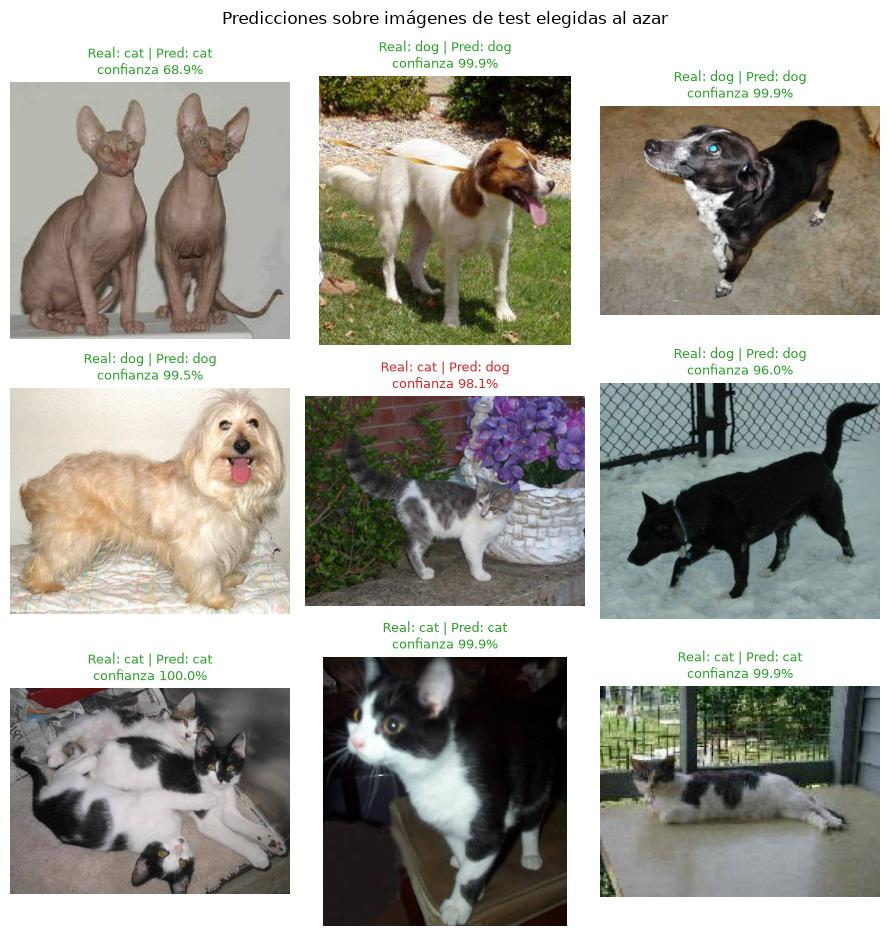

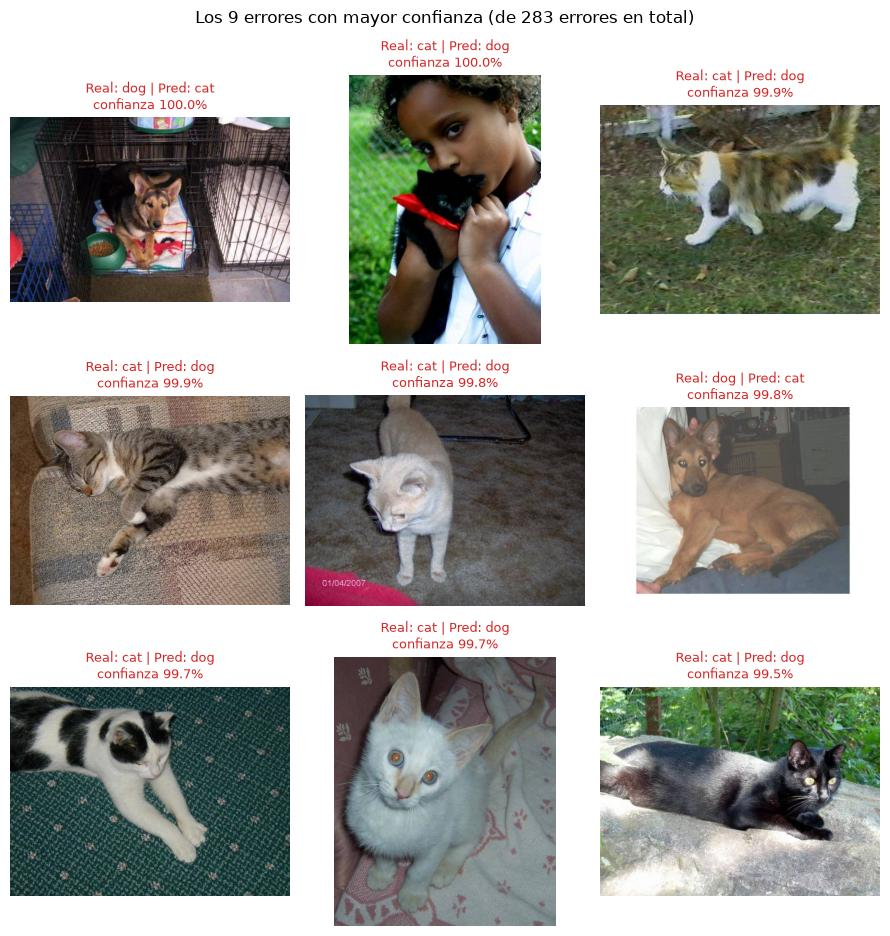

In [8]:
confidences = results["probabilities"].max(axis=1)
filepaths = np.array(results["filepaths"])
labels, predictions = results["labels"], results["predictions"]

rng = np.random.default_rng(42)
sample = rng.choice(len(filepaths), size=9, replace=False)
plot_predictions(
    filepaths[sample], labels[sample], predictions[sample], confidences[sample], CLASSES,
    "Predicciones sobre imágenes de test elegidas al azar",
)

errors = np.flatnonzero(labels != predictions)
worst_errors = errors[np.argsort(-confidences[errors])][:9]
plot_predictions(
    filepaths[worst_errors], labels[worst_errors], predictions[worst_errors], confidences[worst_errors], CLASSES,
    f"Los 9 errores con mayor confianza (de {len(errors)} errores en total)",
)

## Paso 5: modelo guardado

`ModelCheckpoint` almacenó el mejor modelo en la carpeta `models/`. La evaluación anterior lo cargó desde ese archivo con `keras.models.load_model()`, lo que confirma que se guardó correctamente y puede reutilizarse sin volver a entrenar.

In [9]:
size_mb = BEST_MODEL_PATH.stat().st_size / 1024**2
print(f"{BEST_MODEL_PATH.relative_to(PROJECT_ROOT)} ({size_mb:.1f} MB)")
print(f"{HISTORY_PATH.relative_to(PROJECT_ROOT)} (historial de entrenamiento)")

models/efficientnet_dogs_vs_cats.keras (48.9 MB)
models/training_history.json (historial de entrenamiento)


## Conclusiones

**Resultado.** La red `EfficientNet-B0` entrenada desde cero alcanza una **precisión del 94,3% en test** (pérdida 0,150) sobre 5.000 imágenes que nunca vio durante el entrenamiento. Supera con claridad el 80% del SVM de 2007 que demostró que Asirra ya no servía como CAPTCHA: el modelo falla en 1 de cada 18 fotos frente a 1 de cada 5.

**Errores.** De los 283 fallos, 190 son gatos clasificados como perro y 93 perros clasificados como gato:

| Clase | Precisión | Recall | F1 |
|---|---|---|---|
| cat | 96,1% | 92,4% | 94,2% |
| dog | 92,7% | 96,3% | 94,4% |

El modelo tiende a responder "perro" cuando duda: cuando dice "gato" casi siempre acierta (precisión 96,1%), pero se le escapan más gatos (recall 92,4%). Entre los errores con más confianza aparecen situaciones difíciles como las que anticipaba el enunciado: animales tras rejas o jaulas, una persona que ocupa la mayor parte de la foto, gatos tumbados y estirados en posturas poco habituales o con colores y fondos que también son comunes en fotos de perros. Además, varios errores tienen una confianza cercana al 100%, lo que indica que el modelo está **sobreconfiado**: sus probabilidades no reflejan bien la incertidumbre real.

**Entrenamiento.** `EarlyStopping` y `ModelCheckpoint` fueron decisivos: la validación fluctuó varias veces (épocas 4, 6 y 13) y desde la época 16 el modelo empezó a sobreajustar (97% en train frente a ~92% en validación). Gracias a `patience=3` el entrenamiento no se detuvo en los primeros baches, y gracias a `restore_best_weights` y `save_best_only` se conservó el modelo de la época 15 en lugar del último.

**Posibles mejoras.**

- **Transfer learning**: usar `weights="imagenet"` y reentrenar solo las últimas capas probablemente superaría el 97% en pocas épocas y con mucho menos cómputo, porque la red ya sabe reconocer formas, texturas y animales.
- **Más aumento de datos** (rotaciones, zoom, desplazamientos, cambios de brillo) para reducir el sobreajuste y hacer el modelo más robusto a animales en esquinas o parcialmente tapados.
- **Reducir la tasa de aprendizaje** cuando la validación se estanca (`ReduceLROnPlateau`) para suavizar las oscilaciones de las últimas épocas.
- **Regularización** (`Dropout` antes de la capa densa o *label smoothing*) para bajar la sobreconfianza en las predicciones.